# MANOVA: Multivariate Analysis of Variance

## Overview
MANOVA extends ANOVA to situations with **multiple continuous response variables** measured simultaneously. Rather than running separate ANOVAs (inflating Type I error), MANOVA tests whether group centroids differ in multivariate space.

| Feature | ANOVA | MANOVA |
|---|---|---|
| Response variables | 1 | p ≥ 2 |
| Test statistic | F | Pillai, Wilks, Hotelling-Lawley, Roy |
| Accounts for correlation among responses | — | ✓ |
| Sensitive to multivariate outliers | less so | more so |

**Typical ecological use:** comparing species assemblage composition (multiple species counts), morphometric measurements (length, width, mass), or physiological profiles across treatments.

**Relation to PERMANOVA:** PERMANOVA (in `05_multivariate/permanova`) uses permutation rather than parametric assumptions and handles non-Euclidean distances — preferred for species-abundance data. MANOVA is appropriate when responses are continuous, multivariate normal, and measured on a common scale.

**Reference:** Quinn & Keough (2002) ch. 16

---

In [1]:
library(tidyverse); library(car); library(mvnormtest); library(biotools)
set.seed(42)
# Morphometric data: 3 intertidal snail species, 4 measurements each
# Response: shell_length, shell_width, aperture_height, body_mass
species <- rep(c("littorina", "monodonta", "gibbula"), each = 30)
mu_list <- list(
  littorina = c(18, 12, 9, 1.2),
  monodonta  = c(22, 15, 11, 1.8),
  gibbula    = c(15, 11, 7, 0.9)
)
Sigma <- matrix(c(4,1.5,1.2,0.4, 1.5,3,1.0,0.3,
                   1.2,1.0,2,0.25, 0.4,0.3,0.25,0.15), 4, 4)
dat <- do.call(rbind, lapply(species, function(sp) {
  MASS::mvrnorm(1, mu = mu_list[[sp]], Sigma = Sigma)
})) |> as.data.frame()
colnames(dat) <- c("shell_length", "shell_width", "aperture_height", "body_mass")
dat$species <- factor(species)

cat("Dataset: n =", nrow(dat), "\nSpecies means:\n")
dat |> group_by(species) |>
  summarise(across(shell_length:body_mass, \(x) round(mean(x), 2))) |> print()

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'car' was built under R version 4.4.3"
Loading required package: carData

Warning message:
"package 'carDat

Dataset: n = 90 
Species means:
# A tibble: 3 × 5
  species   shell_length shell_width aperture_height body_mass
  <fct>            <dbl>       <dbl>           <dbl>     <dbl>
1 gibbula           14.6        10.4            6.34      0.86
2 littorina         18.3        12.2            9.55      1.2 
3 monodonta         21.5        14.7           10.7       1.78


---
## Assumptions check

In [3]:
# 1. Multivariate normality (Henze-Zirkler test via mvnormtest)
cat("--- Multivariate normality (Henze-Zirkler) by species ---\n")
for (sp in levels(dat$species)) {
  sub <- dat |> dplyr::filter(species == sp) |>
    dplyr::select(shell_length:body_mass) |> t()
  hw <- mshapiro.test(sub)
  cat(sp, ": W =", round(hw$statistic, 4), ", p =", round(hw$p.value, 4), "\n")
}

# 2. Homogeneity of covariance matrices (Box's M)
# using biotools::boxM — heplots unavailable due to xfun conflict
bm <- biotools::boxM(dat[, 1:4], dat$species)
cat("\nBox's M test:\n"); print(bm)
cat("(Box's M is sensitive to non-normality; minor violations tolerable with equal n)\n")

# 3. Check for multivariate outliers (Mahalanobis distance)
cat("\nMahalanobis distances (outliers > chi2 0.001 threshold):\n")
grand_cov <- cov(dat[, 1:4])
grand_mu  <- colMeans(dat[, 1:4])
mahal     <- mahalanobis(dat[, 1:4], center = grand_mu, cov = grand_cov)
thresh    <- qchisq(0.999, df = 4)
cat("Threshold (chi2, df=4, p=0.001):", round(thresh, 2), "\n")
cat("Potential outliers:", sum(mahal > thresh), "rows\n")

--- Multivariate normality (Henze-Zirkler) by species ---


gibbula : W = 0.9614 , p = 0.3356 
littorina : W = 0.9195 , p = 0.026 
monodonta : W = 0.9494 , p = 0.1625 

Box's M test:

	Box's M-test for Homogeneity of Covariance Matrices

data:  dat[, 1:4]
Chi-Sq (approx.) = 13.743, df = 20, p-value = 0.8433

(Box's M is sensitive to non-normality; minor violations tolerable with equal n)

Mahalanobis distances (outliers > chi2 0.001 threshold):
Threshold (chi2, df=4, p=0.001): 18.47 
Potential outliers: 0 rows


---
## Fit MANOVA and test statistics

In [4]:
# Bind response matrix
Y <- as.matrix(dat[, c("shell_length", "shell_width", "aperture_height", "body_mass")])

# Fit MANOVA
m_man <- manova(Y ~ species, data = dat)

# Four test statistics — each emphasises different aspects of separation
cat("=== Pillai's Trace (most robust to assumption violations) ===\n")
print(summary(m_man, test = "Pillai"))

cat("\n=== Wilks' Lambda (likelihood ratio; most powerful when assumptions met) ===\n")
print(summary(m_man, test = "Wilks"))

cat("\n=== Hotelling-Lawley Trace (emphasises largest canonical root) ===\n")
print(summary(m_man, test = "Hotelling-Lawley"))

cat("\n=== Roy's Greatest Root (most powerful for one dimension; inflated p) ===\n")
print(summary(m_man, test = "Roy"))

=== Pillai's Trace (most robust to assumption violations) ===
          Df  Pillai approx F num Df den Df    Pr(>F)    
species    2 0.98197   20.497      8    170 < 2.2e-16 ***
Residuals 87                                             
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

=== Wilks' Lambda (likelihood ratio; most powerful when assumptions met) ===
          Df   Wilks approx F num Df den Df    Pr(>F)    
species    2 0.17807   28.765      8    168 < 2.2e-16 ***
Residuals 87                                             
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

=== Hotelling-Lawley Trace (emphasises largest canonical root) ===
          Df Hotelling-Lawley approx F num Df den Df    Pr(>F)    
species    2            3.717   38.564      8    166 < 2.2e-16 ***
Residuals 87                                                      
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

=== Roy's Greatest Root (most powerful fo

--- Follow-up univariate ANOVAs (Bonferroni-corrected alpha = 0.05/4 = 0.0125) ---
 Response shell_length :
            Df Sum Sq Mean Sq F value    Pr(>F)    
species      2 707.19  353.59  102.06 < 2.2e-16 ***
Residuals   87 301.41    3.46                      
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

 Response shell_width :
            Df Sum Sq Mean Sq F value    Pr(>F)    
species      2 276.26 138.129  49.181 5.132e-15 ***
Residuals   87 244.35   2.809                      
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

 Response aperture_height :
            Df Sum Sq Mean Sq F value    Pr(>F)    
species      2 308.69 154.347  93.999 < 2.2e-16 ***
Residuals   87 142.86   1.642                      
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

 Response body_mass :
            Df Sum Sq Mean Sq F value    Pr(>F)    
species      2 12.957  6.4784  42.771 1.159e-13 ***
Residuals   87 13.178  0.1515             

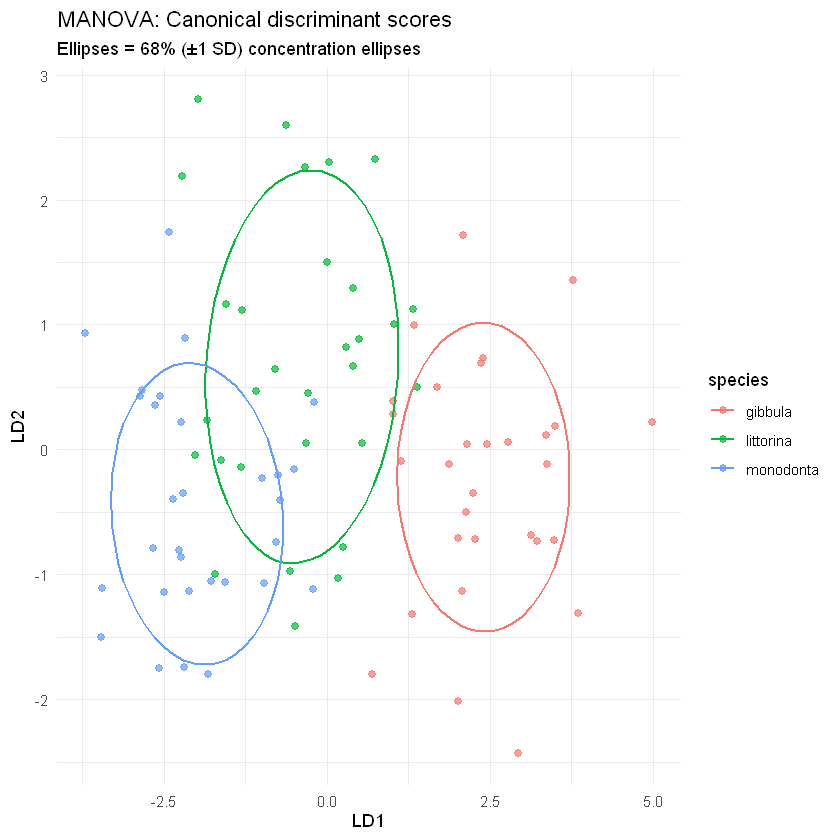

In [5]:
# Follow-up: univariate ANOVAs (with Bonferroni correction)
cat("--- Follow-up univariate ANOVAs (Bonferroni-corrected alpha = 0.05/4 = 0.0125) ---\n")
print(summary.aov(m_man))

# Canonical discriminant analysis to visualise group separation
# (using MASS::lda as geometric view of MANOVA structure)
cat("\n--- Canonical discriminant scores (first 2 axes) ---\n")
lda_fit <- MASS::lda(species ~ shell_length + shell_width +
                      aperture_height + body_mass, data = dat)
scores <- predict(lda_fit)$x |> as.data.frame()
scores$species <- dat$species

ggplot(scores, aes(LD1, LD2, colour = species)) +
  geom_point(alpha = 0.7, size = 2) +
  stat_ellipse(level = 0.68, linewidth = 0.8) +
  labs(title = "MANOVA: Canonical discriminant scores",
       subtitle = "Ellipses = 68% (±1 SD) concentration ellipses",
       x = "LD1", y = "LD2") +
  theme_minimal()

In [6]:
# Effect sizes: eta-squared for each response
cat("--- Effect sizes (eta-squared) for each response variable ---\n")
for (resp in c("shell_length", "shell_width", "aperture_height", "body_mass")) {
  aov_fit <- aov(reformulate("species", response = resp), data = dat)
  ss <- summary(aov_fit)[[1]][["Sum Sq"]]
  eta2 <- ss[1] / sum(ss)
  cat(sprintf("  %-20s eta2 = %.3f\n", resp, eta2))
}

# Pillai's trace as overall effect size
man_sum <- summary(m_man, test = "Pillai")
cat("\nOverall Pillai's trace:", round(man_sum$stats[1, "Pillai"], 3),
    "(ranges 0-1; ≈ proportion of variance explained in multivariate space)\n")

--- Effect sizes (eta-squared) for each response variable ---
  shell_length         eta2 = 0.701
  shell_width          eta2 = 0.531
  aperture_height      eta2 = 0.684
  body_mass            eta2 = 0.496

Overall Pillai's trace: 0.982 (ranges 0-1; ≈ proportion of variance explained in multivariate space)


---
## Common Pitfalls

**1. Running multiple separate ANOVAs instead of MANOVA**
With p response variables and α = 0.05, the probability of at least one false positive is 1 − 0.95^p. MANOVA controls the experiment-wise error rate and accounts for correlations among responses.

**2. Choosing the wrong test statistic**
Pillai's trace is most robust when assumptions are violated (heterogeneous covariances, non-normality, small samples) — use it by default. Wilks' lambda is most powerful when all assumptions hold. Roy's greatest root is powerful but inflated when group separation is multi-dimensional; avoid unless testing a single canonical dimension.

**3. Proceeding with MANOVA when Box's M is significant but n is unequal**
Box's M is extremely sensitive to non-normality and unequal n. A significant result with unequal group sizes is a real problem because MANOVA is not robust to heterogeneous covariances in this scenario. Either balance the design or use PERMANOVA.

**4. Ignoring multivariate outliers**
A single multivariate outlier can dominate the covariance matrix and invalidate the test even when all univariate values look reasonable. Always check Mahalanobis distances.

**5. Interpreting follow-up univariate ANOVAs as independent tests**
Follow-up ANOVAs identify which responses drive the multivariate effect but should use a corrected α (Bonferroni or Holm). They are descriptive, not confirmatory — the primary inference comes from the MANOVA test.

**6. Using MANOVA for species-abundance data**
Ecological community data (species counts, presence/absence) rarely meet multivariate normality and equal-covariance assumptions. Use PERMANOVA (vegan::adonis2) instead, which makes no distributional assumptions.


---
*r_methods_library - Samantha McGarrigle*